In [1]:
import os
import google.generativeai as genai
from PIL import Image
from dotenv import load_dotenv
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



# 1. Authenticate using your API key
load_dotenv()
api_key = os.environ.get("GEMINI_API_KEY")
if not api_key:
    raise ValueError("Please set the GEMINI_API_KEY environment variable.")
genai.configure(api_key=api_key)

# 2. Initialize the model (Gemini 1.5 Flash is incredibly fast and cheap for this)
model = genai.GenerativeModel('gemini-2.5-flash')

def classify_overhead_vehicle(reference_data, target_image_path):
    """
    Takes a list of reference images + labels, and classifies a new target image.
    """
    print(f"Loading {len(reference_data)} context images...")
    
    # Set up the strict system instruction
    prompt_contents = [
        "You are an expert satellite and drone imagery analyst. "
        "I will provide you with several examples of vehicles from an overhead view, along with their correct classifications. "
        "Then, I will give you a target image. You must classify the target image into exactly one of these 4 categories: SUV, sedan, truck, bus. "
        "Do not provide any explanations. Output ONLY the category name.\n"
    ]

    # Append the 20 few-shot examples to the prompt sequentially
    for img_path, label in reference_data:
        img = Image.open(img_path)
        prompt_contents.append(img)
        prompt_contents.append(f"Label: {label}\n")

    # Append the final target image we want to actually classify
    prompt_contents.append("Now, classify this target image based strictly on the visual patterns above.")
    target_img = Image.open(target_image_path)
    prompt_contents.append(target_img)
    prompt_contents.append("Target Label:")

    print("Sending multi-image payload to the VLM...")
    
    # Call the VLM with the massive multi-image payload
    response = model.generate_content(prompt_contents)
    
    return response.text.strip()


if __name__ == "__main__":
    
    ## Context
    examples = [
    (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-15-18-28_png.rf.28fc4b45cbb7cc0375a0a1d013da7acb.jpg", "SUV"),
    (r'D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-14-51-53_png.rf.a420675aec9d267a4918e4f6b624b938.jpg', "SUV"),
    (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-14-49-01_png.rf.0a93df9f0be46f0eb90eac2282fc5347.jpg", "SUV"),
    (r"D:\CV_Project\data\cars.v1i.coco\crops\DJI-00760-00001-1-_jpg.rf.ccecf9a0ecc8984c01aaa5fa25516594_ann10.jpg", "SUV"),
    (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-15-17-59_png.rf.f83a7cd8ff5091d85bcd518ba63638ef.jpg", "sedan"),
    (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-14-44-24_png.rf.9ecb63672a6e06a87bf5875b063d626d.jpg", "sedan"),
    (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-15-02-04_png.rf.e778e47b1e388c7441c2fae1c630ec89.jpg", "sedan"),
    (r"D:\CV_Project\data\cars.v1i.coco\crops\DJI_0005-0071_jpg.rf.85e28363e268a259ced325858f5ea023_ann5.jpg", "sedan"),
    (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-15-05-15_png.rf.863275a545cedd225d0060f8e92e7fc7.jpg", "truck"),
    (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-15-04-52_png.rf.0d6db9bde6f4d40692ce4001d5010966.jpg", "truck"),
    (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-14-55-05_png.rf.da96e0c9ae878062bf8cf23474468091.jpg", "truck"),
    (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-14-54-08_png.rf.1fcb78dec3616ec5983678d61ed74729.jpg", "truck"),
    (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-15-17-07_png.rf.710f4176b646d40b2b99c564172586ca.jpg", "bus"),
    (r"D:\CV_Project\data\cars.v1i.coco\crops\Screenshot-from-2026-02-12-14-59-11_png.rf.b5726dd264543f89310fff9334907344_ann15.jpg", "bus"),
    (r"D:\CV_Project\data\cars.v1i.coco\crops\Screenshot-from-2026-02-12-14-58-26_png.rf.eca11b21c6c6bfd088b7970f4a99e3ac_ann18.jpg", "bus"),
    (r"D:\CV_Project\data\cars.v1i.coco\crops\DJI_0762-00031_jpg.rf.abb1115b71b8b0ff871968c8daf083ea_ann14.jpg", "bus"),

    ]

C:\Users\YASER\AppData\Local\Temp\ipykernel_30252\3471821519.py:2: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [ ]:
# new_image_to_test = r"D:\CV_Project\test\SUV2.png"
    

# prediction = classify_overhead_vehicle(examples, new_image_to_test)
# print(f"\n✅ SUCCESS! The model classified the vehicle as: {prediction}")


Loading 16 context images...
Sending multi-image payload to the VLM...

✅ SUCCESS! The model classified the vehicle as: SUV


In [4]:
test_images = [
    (r"D:\CV_Project\test\SUV2.png", "SUV"),
    (r"D:\CV_Project\test\truck.png", "truck"),
    (r"D:\CV_Project\test\bus.png", "bus"),
    (r"D:\CV_Project\test\sedan.png", "sedan"),
]

predictions = []
for img_path, true_label in test_images:
    pred = classify_overhead_vehicle(examples, img_path)
    predictions.append({"image": img_path, "true_label": true_label, "predicted_label": pred})

# Create a DataFrame for logging
df = pd.DataFrame(predictions)
df.to_csv("vlm_results.csv", index=False)

class_labels = ["bus", "sedan", "SUV", "truck"] 

# ... (your existing loop to generate the df stays exactly the same) ...

# Evaluate
accuracy = accuracy_score(df["true_label"], df["predicted_label"])
print(f"Overall Accuracy: {accuracy * 100:.1f}%\n")

print("--- Detailed Classification Report ---")
# FIX 1: Add labels=class_labels
print(classification_report(
    df["true_label"], 
    df["predicted_label"], 
    labels=class_labels, 
    target_names=class_labels,
    zero_division=0 # This prevents a warning if a class has 0 predictions
))

print("--- Confusion Matrix ---")
# FIX 2: Add labels=class_labels here too so the matrix is always 4x4
print(confusion_matrix(
    df["true_label"], 
    df["predicted_label"], 
    labels=class_labels
))

Loading 16 context images...
Sending multi-image payload to the VLM...
Loading 16 context images...
Sending multi-image payload to the VLM...
Loading 16 context images...
Sending multi-image payload to the VLM...
Loading 16 context images...
Sending multi-image payload to the VLM...
Overall Accuracy: 100.0%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

         bus       1.00      1.00      1.00         1
       sedan       1.00      1.00      1.00         1
         SUV       1.00      1.00      1.00         1
       truck       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

--- Confusion Matrix ---
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]


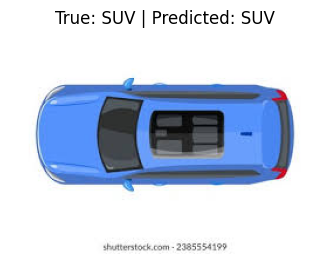

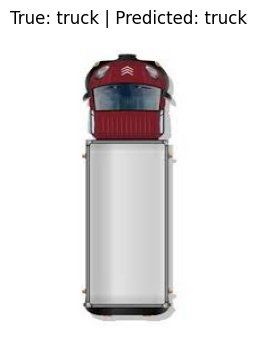

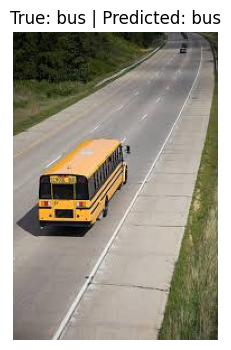

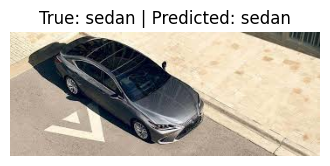

In [5]:
import matplotlib.pyplot as plt
from PIL import Image

# Show results for each test image
for idx, row in df.iterrows():
    img = Image.open(row["image"])
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"True: {row['true_label']} | Predicted: {row['predicted_label']}")
    plt.axis("off")
    plt.show()